In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Connect to (or create) the database file
conn = sqlite3.connect("bank.db")
cursor = conn.cursor()

# Create the table
cursor.execute("DROP TABLE IF EXISTS balance_sheet")
conn.commit()
cursor.execute("""
    CREATE TABLE IF NOT EXISTS balance_sheet (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        item TEXT,
        side TEXT,
        notional REAL,
        rate REAL,
        repricing_years REAL,
        duration_years REAL
    )
""")

# Insert balance sheet items
items = [
    ("Floating Rate Mortgages",   "asset",     500_000_000, 0.055, 0.5,  0.5),
    ("Fixed Rate Mortgages",      "asset",     300_000_000, 0.048, 5.0,  4.2),
    ("Corporate Loans (float)",   "asset",     200_000_000, 0.060, 1.0,  1.0),
    ("Government Bonds",          "asset",     100_000_000, 0.035, 7.0,  5.8),
    ("Cash & Reserves",           "asset",      50_000_000, 0.040, 0.25, 0.25),
    ("Demand Deposits",           "liability", 400_000_000, 0.010, 0.25, 0.25),
    ("Fixed Term Deposits (1yr)", "liability", 250_000_000, 0.030, 1.0,  0.95),
    ("Fixed Term Deposits (3yr)", "liability", 200_000_000, 0.038, 3.0,  2.7),
    ("Senior Unsecured Bonds",    "liability", 200_000_000, 0.042, 5.0,  4.5),
    ("Equity",                    "liability", 100_000_000, 0.000, 0, 0),
]

cursor.executemany("""
    INSERT INTO balance_sheet (item, side, notional, rate, repricing_years, duration_years)
    VALUES (?, ?, ?, ?, ?, ?)
""", items)

conn.commit()
print("Database created and populated successfully.")

Database created and populated successfully.


In [2]:
df = pd.read_sql("SELECT * FROM balance_sheet", conn)
df

,id,item,side,notional,rate,repricing_years,duration_years
0,1,Floating Rate Mortgages,asset,500000000.0,0.055,0.50,0.50
1,2,Fixed Rate Mortgages,asset,300000000.0,0.048,5.00,4.20
2,3,Corporate Loans (float),asset,200000000.0,0.060,1.00,1.00
3,4,Government Bonds,asset,100000000.0,0.035,7.00,5.80
4,5,Cash & Reserves,asset,50000000.0,0.040,0.25,0.25
5,6,Demand Deposits,liability,400000000.0,0.010,0.25,0.25
6,7,Fixed Term Deposits (1yr),liability,250000000.0,0.030,1.00,0.95
7,8,Fixed Term Deposits (3yr),liability,200000000.0,0.038,3.00,2.70
8,9,Senior Unsecured Bonds,liability,200000000.0,0.042,5.00,4.50
9,10,Equity,liability,100000000.0,0.000,0.00,0.00


In [3]:
# Define time buckets
def assign_bucket(repricing_years):
    if repricing_years <= 0.25:
        return "0-3 months"
    elif repricing_years <= 1.0:
        return "3-12 months"
    elif repricing_years <= 3.0:
        return "1-3 years"
    elif repricing_years <= 5.0:
        return "3-5 years"
    else:
        return "5+ years"

# Query assets and liabilities separately using SQL
assets = pd.read_sql("SELECT * FROM balance_sheet WHERE side = 'asset'", conn)
liabilities = pd.read_sql("SELECT * FROM balance_sheet WHERE side = 'liability' AND item != 'Equity'", conn)

# Assign buckets
assets["bucket"] = assets["repricing_years"].apply(assign_bucket)
liabilities["bucket"] = liabilities["repricing_years"].apply(assign_bucket)

In [4]:
bucket_order = ["0-3 months", "3-12 months", "1-3 years", "3-5 years", "5+ years"]

# Sum notional per bucket for each side
asset_buckets = assets.groupby("bucket")["notional"].sum().reindex(bucket_order, fill_value=0)
liability_buckets = liabilities.groupby("bucket")["notional"].sum().reindex(bucket_order, fill_value=0)

# Gap = assets - liabilities per bucket
gap = asset_buckets - liability_buckets

print("Repricing Gap per Bucket (MNOK):")
for bucket, val in gap.items():
    direction = "asset sensitive ↑" if val > 0 else "liability sensitive ↓"
    print(f"  {bucket:<18}: {val/1e6:>+8.1f}M NOK  ({direction})")

Repricing Gap per Bucket (MNOK):
  0-3 months        :   -350.0M NOK  (liability sensitive ↓)
  3-12 months       :   +450.0M NOK  (asset sensitive ↑)
  1-3 years         :   -200.0M NOK  (liability sensitive ↓)
  3-5 years         :   +100.0M NOK  (asset sensitive ↑)
  5+ years          :   +100.0M NOK  (asset sensitive ↑)


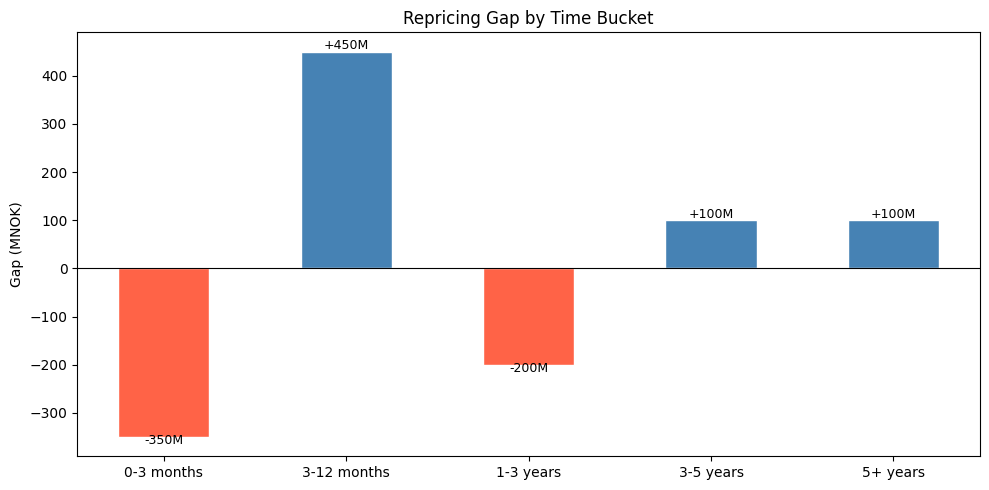

In [5]:
colours = ["steelblue" if v >= 0 else "tomato" for v in gap.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(gap.index, gap.values / 1_000_000, color=colours, edgecolor="white", width=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Gap (MNOK)")
ax.set_title("Repricing Gap by Time Bucket")

for bar, val in zip(bars, gap.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val / 1e6 + (5 if val >= 0 else -15),
            f"{val/1e6:+.0f}M",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# Query full balance sheet from SQL
df = pd.read_sql("SELECT * FROM balance_sheet WHERE item != 'Equity'", conn)

# Calculate base annual interest for each item
df["annual_interest"] = df["notional"] * df["rate"]

# Base NII = total asset income - total liability cost
base_nii = (
    df[df["side"] == "asset"]["annual_interest"].sum() -
    df[df["side"] == "liability"]["annual_interest"].sum()
)

print(f"Base NII: {base_nii:>15,.0f} NOK")
print(f"Base NII: {base_nii/1e6:>15.2f}M NOK")

Base NII:      31,900,000 NOK
Base NII:           31.90M NOK


In [7]:
# Basel standard parallel shocks (in basis points converted to decimals)
shocks = [-0.02, -0.01, 0.01, 0.02, 0.03]
shock_labels = ["-200bps", "-100bps", "+100bps", "+200bps", "+300bps"]

nii_results = []

for shock in shocks:
    shocked_nii = 0
    for _, row in df.iterrows():
        # Only items repricing within 1 year are affected in year 1
        if row["repricing_years"] <= 1.0:
            new_rate = row["rate"] + shock
        else:
            new_rate = row["rate"]

        interest = row["notional"] * new_rate

        if row["side"] == "asset":
            shocked_nii += interest
        else:
            shocked_nii -= interest

    delta_nii = shocked_nii - base_nii
    nii_results.append(delta_nii)
    print(f"  {shock*10000:>+.0f}bps  →  ΔNII: {delta_nii/1e6:>+.2f}M NOK")

  -200bps  →  ΔNII: -2.00M NOK
  -100bps  →  ΔNII: -1.00M NOK
  +100bps  →  ΔNII: +1.00M NOK
  +200bps  →  ΔNII: +2.00M NOK
  +300bps  →  ΔNII: +3.00M NOK


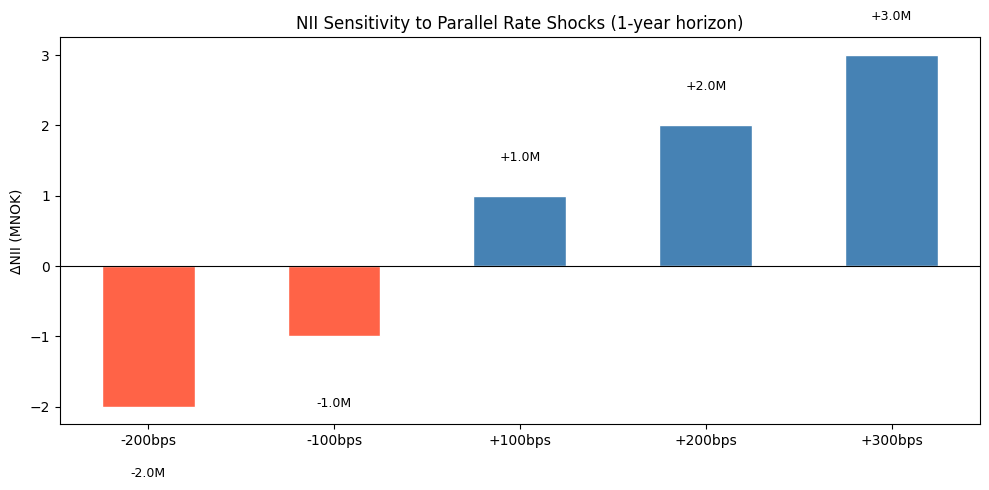

In [8]:
colours = ["steelblue" if v >= 0 else "tomato" for v in nii_results]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(shock_labels, [v / 1e6 for v in nii_results],
              color=colours, edgecolor="white", width=0.5)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("ΔNII (MNOK)")
ax.set_title("NII Sensitivity to Parallel Rate Shocks (1-year horizon)")

for bar, val in zip(bars, nii_results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val / 1e6 + (0.5 if val >= 0 else -1),
            f"{val/1e6:+.1f}M",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# Basel standard shocks — same as Stage 2
shocks = [-0.02, -0.01, 0.01, 0.02, 0.03]
shock_labels = ["-200bps", "-100bps", "+100bps", "+200bps", "+300bps"]

# Tier 1 Capital proxy (equity notional from balance sheet)
tier1_capital = pd.read_sql("SELECT notional FROM balance_sheet WHERE item = 'Equity'", conn)["notional"].values[0]
threshold = 0.15 * tier1_capital  # 15% Basel IRRBB regulatory limit

eve_results = []

print(f"Tier 1 Capital (proxy): {tier1_capital/1e6:.0f}M NOK")
print(f"15% EVE threshold:      {threshold/1e6:.1f}M NOK")
print()

for shock in shocks:
    delta_eve = 0
    for _, row in df.iterrows():
        # Change in present value using duration approximation:
        # ΔPV = -duration * (shock / (1 + base_rate)) * notional
        delta_pv = -row["duration_years"] * (shock / (1 + row["rate"])) * row["notional"]

        if row["side"] == "asset":
            delta_eve += delta_pv
        else:
            delta_eve -= delta_pv

    eve_results.append(delta_eve)

    # Flag if breach exceeds regulatory threshold
    breach = "⚠️  BREACH" if abs(delta_eve) > threshold else "OK"
    print(f"  {shock*10000:>+.0f}bps  →  ΔEVE: {delta_eve/1e6:>+7.1f}M NOK  {breach}")

Tier 1 Capital (proxy): 100M NOK
15% EVE threshold:      15.0M NOK

  -200bps  →  ΔEVE:    +9.7M NOK  OK
  -100bps  →  ΔEVE:    +4.9M NOK  OK
  +100bps  →  ΔEVE:    -4.9M NOK  OK
  +200bps  →  ΔEVE:    -9.7M NOK  OK
  +300bps  →  ΔEVE:   -14.6M NOK  OK


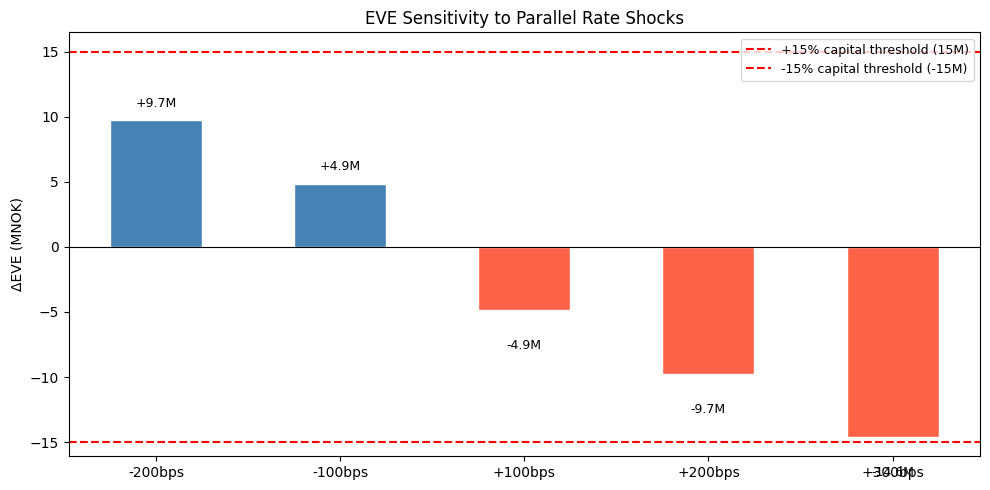

In [10]:
colours = ["steelblue" if v >= 0 else "tomato" for v in eve_results]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(shock_labels, [v / 1e6 for v in eve_results],
              color=colours, edgecolor="white", width=0.5)

# Regulatory threshold lines
ax.axhline(threshold / 1e6, color="red", linewidth=1.5,
           linestyle="--", label=f"+15% capital threshold ({threshold/1e6:.0f}M)")
ax.axhline(-threshold / 1e6, color="red", linewidth=1.5,
           linestyle="--", label=f"-15% capital threshold (-{threshold/1e6:.0f}M)")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("ΔEVE (MNOK)")
ax.set_title("EVE Sensitivity to Parallel Rate Shocks")
ax.legend(fontsize=9)

for bar, val in zip(bars, eve_results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val / 1e6 + (1 if val >= 0 else -3),
            f"{val/1e6:+.1f}M",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
df_eve = pd.read_sql("SELECT * FROM balance_sheet WHERE item != 'Equity'", conn)

# Steeper: short rates fall, long rates rise
# Flatter: short rates rise, long rates fall
scenarios = {
    "Steeper (short -50bps, long +100bps)": {"short": -0.005, "long": 0.01},
    "Flatter (short +100bps, long -50bps)": {"short": 0.01,   "long": -0.005},
}

# Short = repricing < 1yr, Long = repricing >= 1yr
def get_shock(repricing_years, short_shock, long_shock):
    return short_shock if repricing_years < 1.0 else long_shock

print("=" * 55)
for scenario_name, shocks in scenarios.items():
    print(f"\n{scenario_name}")
    print("-" * 55)

    delta_nii = 0
    delta_eve = 0

    for _, row in df_eve.iterrows():
        shock = get_shock(row["repricing_years"], shocks["short"], shocks["long"])

        # NII — only items repricing within 1 year
        if row["repricing_years"] < 1.0:
            nii_impact = row["notional"] * shock
            if row["side"] == "asset":
                delta_nii += nii_impact
            else:
                delta_nii -= nii_impact

        # EVE — all items
        delta_pv = -row["duration_years"] * (shock / (1 + row["rate"])) * row["notional"]
        if row["side"] == "asset":
            delta_eve += delta_pv
        else:
            delta_eve -= delta_pv

    breach = "⚠️  BREACH" if abs(delta_eve) > threshold else "OK"
    print(f"  ΔNII:  {delta_nii/1e6:>+.2f}M NOK")
    print(f"  ΔEVE:  {delta_eve/1e6:>+.2f}M NOK  {breach}")


Steeper (short -50bps, long +100bps)
-------------------------------------------------------
  ΔNII:  -0.75M NOK
  ΔEVE:  -2.62M NOK  OK

Flatter (short +100bps, long -50bps)
-------------------------------------------------------
  ΔNII:  +1.50M NOK
  ΔEVE:  +0.18M NOK  OK


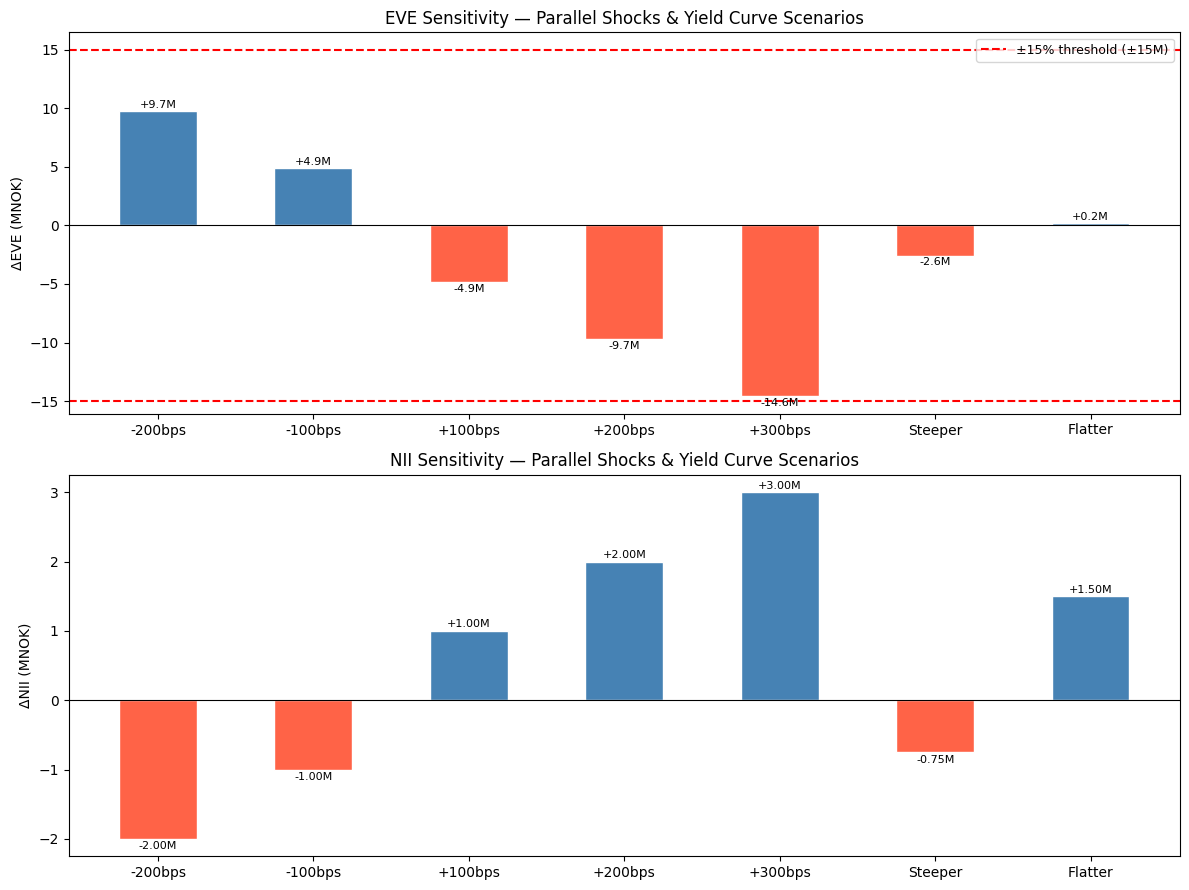

In [14]:
# Combine all scenarios for a summary chart
all_labels = ["-200bps", "-100bps", "+100bps", "+200bps", "+300bps",
              "Steeper", "Flatter"]

# Recalculate steeper and flatter EVE for the chart
eve_curve = []
nii_curve = []

for scenario_name, shocks in scenarios.items():
    d_nii, d_eve = 0, 0
    for _, row in df_eve.iterrows():
        shock = get_shock(row["repricing_years"], shocks["short"], shocks["long"])
        if row["repricing_years"] < 1.0:
            nii_impact = row["notional"] * shock
            d_nii += nii_impact if row["side"] == "asset" else -nii_impact
        delta_pv = -row["duration_years"] * (shock / (1 + row["rate"])) * row["notional"]
        d_eve += delta_pv if row["side"] == "asset" else -delta_pv
    eve_curve.append(d_eve)
    nii_curve.append(d_nii)

all_eve = eve_results + eve_curve
all_nii = nii_results + nii_curve

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# EVE chart
colours_eve = ["steelblue" if v >= 0 else "tomato" for v in all_eve]
bars1 = ax1.bar(all_labels, [v / 1e6 for v in all_eve],
                color=colours_eve, edgecolor="white", width=0.5)
ax1.axhline(threshold / 1e6, color="red", linewidth=1.5,
            linestyle="--", label=f"±15% threshold (±{threshold/1e6:.0f}M)")
ax1.axhline(-threshold / 1e6, color="red", linewidth=1.5, linestyle="--")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_ylabel("ΔEVE (MNOK)")
ax1.set_title("EVE Sensitivity — Parallel Shocks & Yield Curve Scenarios")
ax1.legend(fontsize=9)
for bar, val in zip(bars1, all_eve):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val / 1e6 + (0.3 if val >= 0 else -0.8),
             f"{val/1e6:+.1f}M", ha="center", fontsize=8)

# NII chart
colours_nii = ["steelblue" if v >= 0 else "tomato" for v in all_nii]
bars2 = ax2.bar(all_labels, [v / 1e6 for v in all_nii],
                color=colours_nii, edgecolor="white", width=0.5)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("ΔNII (MNOK)")
ax2.set_title("NII Sensitivity — Parallel Shocks & Yield Curve Scenarios")
for bar, val in zip(bars2, all_nii):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val / 1e6 + (0.05 if val >= 0 else -0.15),
             f"{val/1e6:+.2f}M", ha="center", fontsize=8)

plt.tight_layout()
plt.show()